# LISST 200x Data Processing

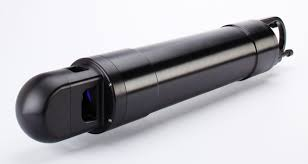

Here I using some files from a campaign in the Patos-Mirim lagoons in April 2025 (AnthroPlast)

1. The instrument generate a '.RBN' file (raw binary n????)
2. The file can be open in the Sequoia proprietary software 'L200XDesktopUI.exe' <the user manual talk about a 'LISST-SOP200X'?>
<div>
    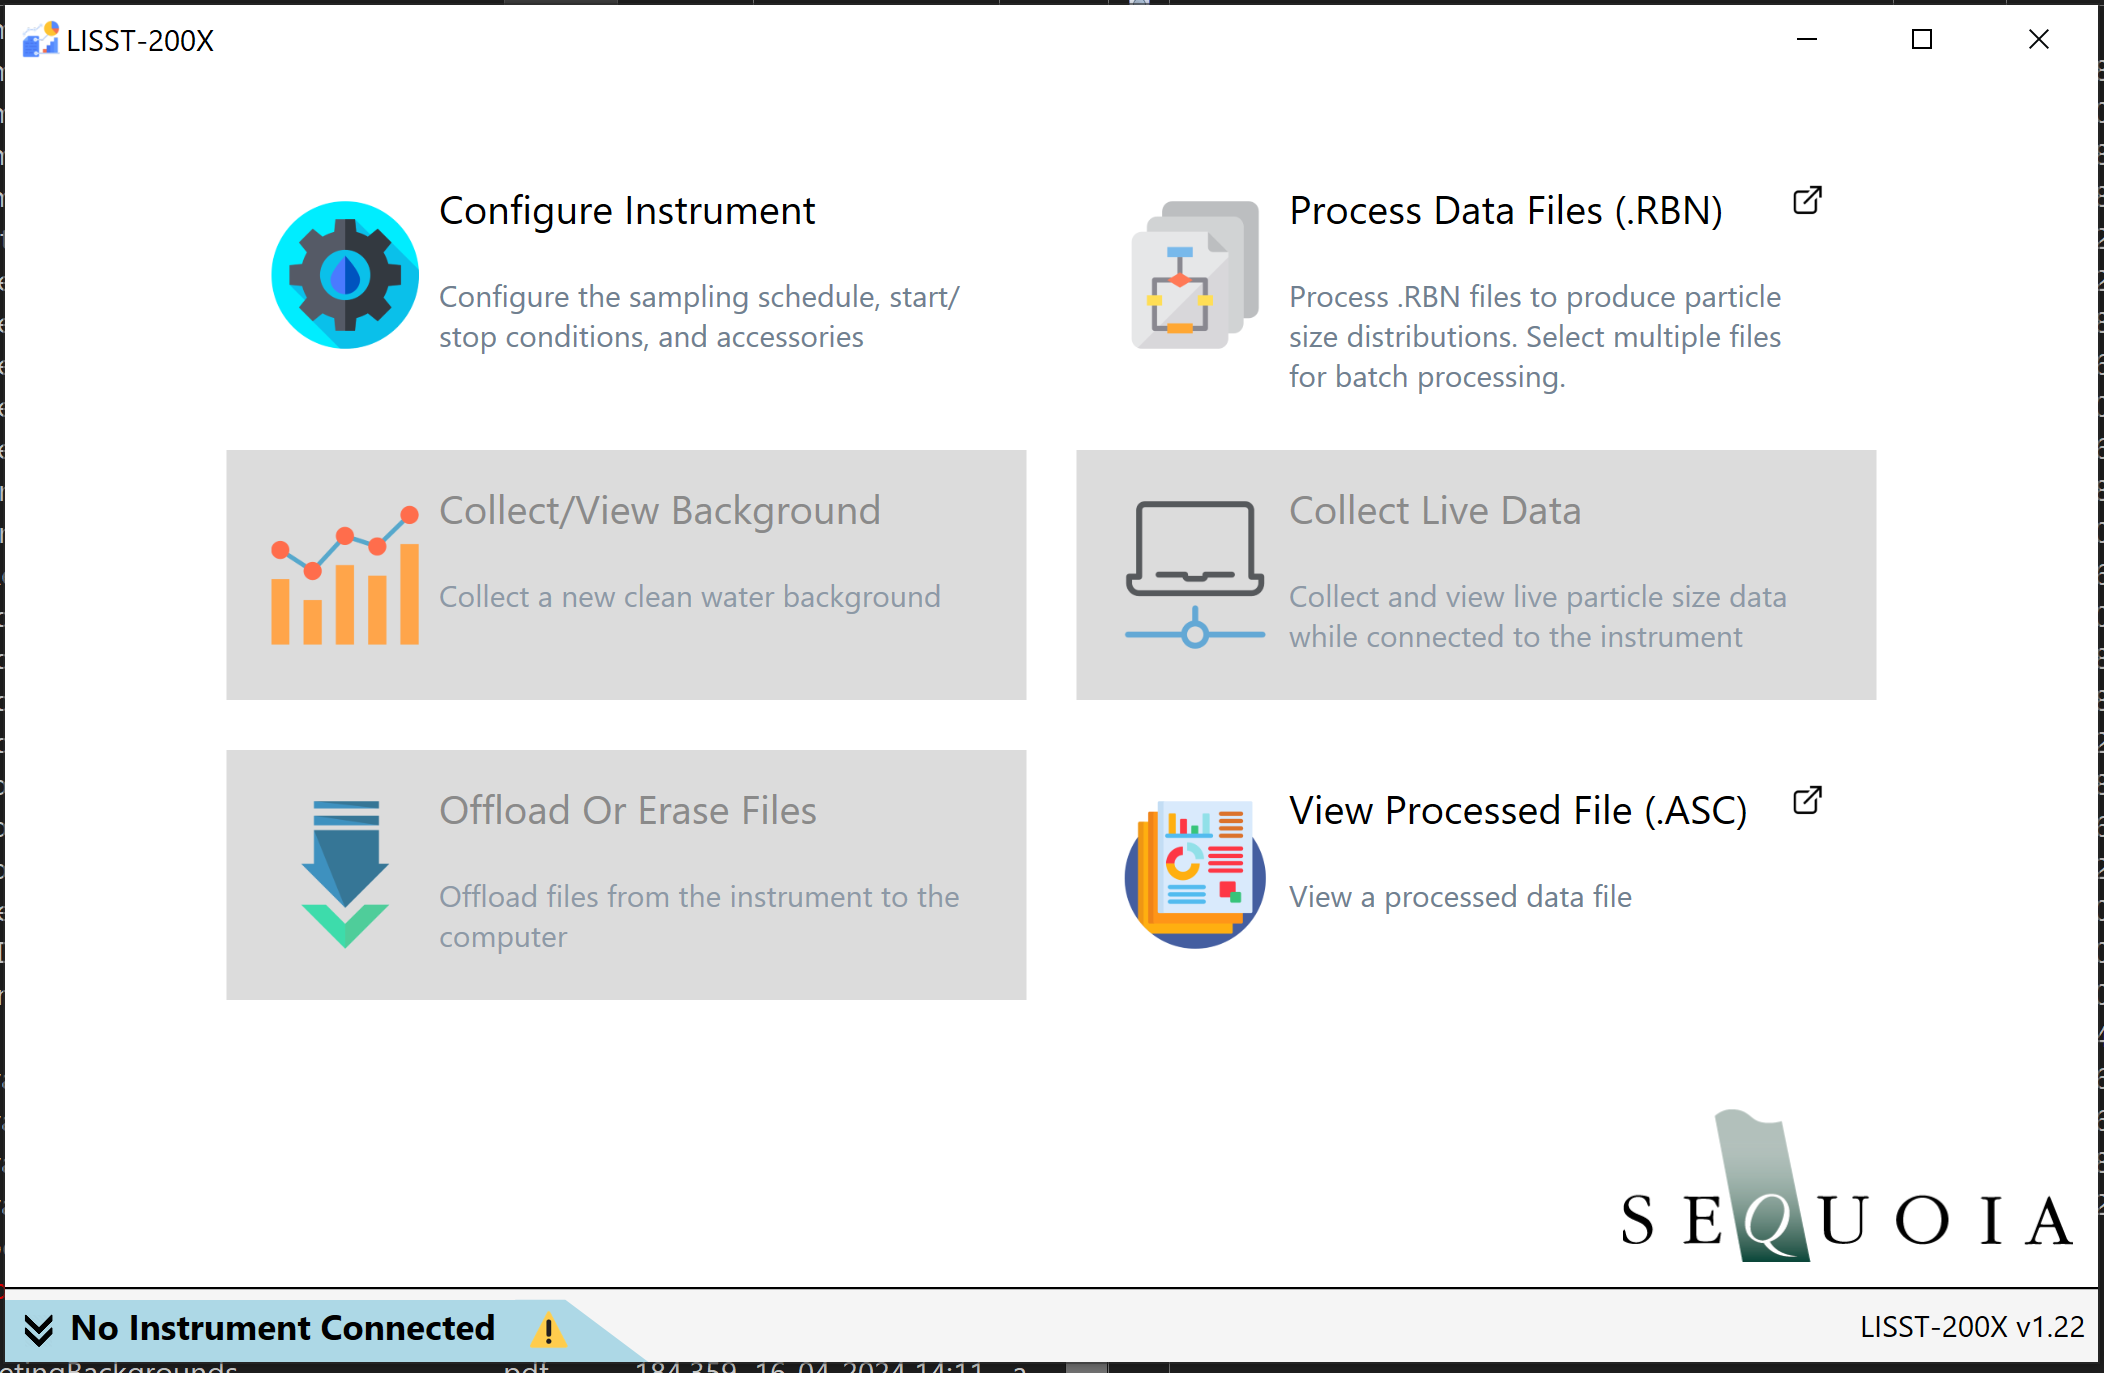
</div>
3. To open and process the data (convert in physical units) --> Process Data Files (.RBN)
4. Choose the path, and mark multiple files for batch processing
<div>
    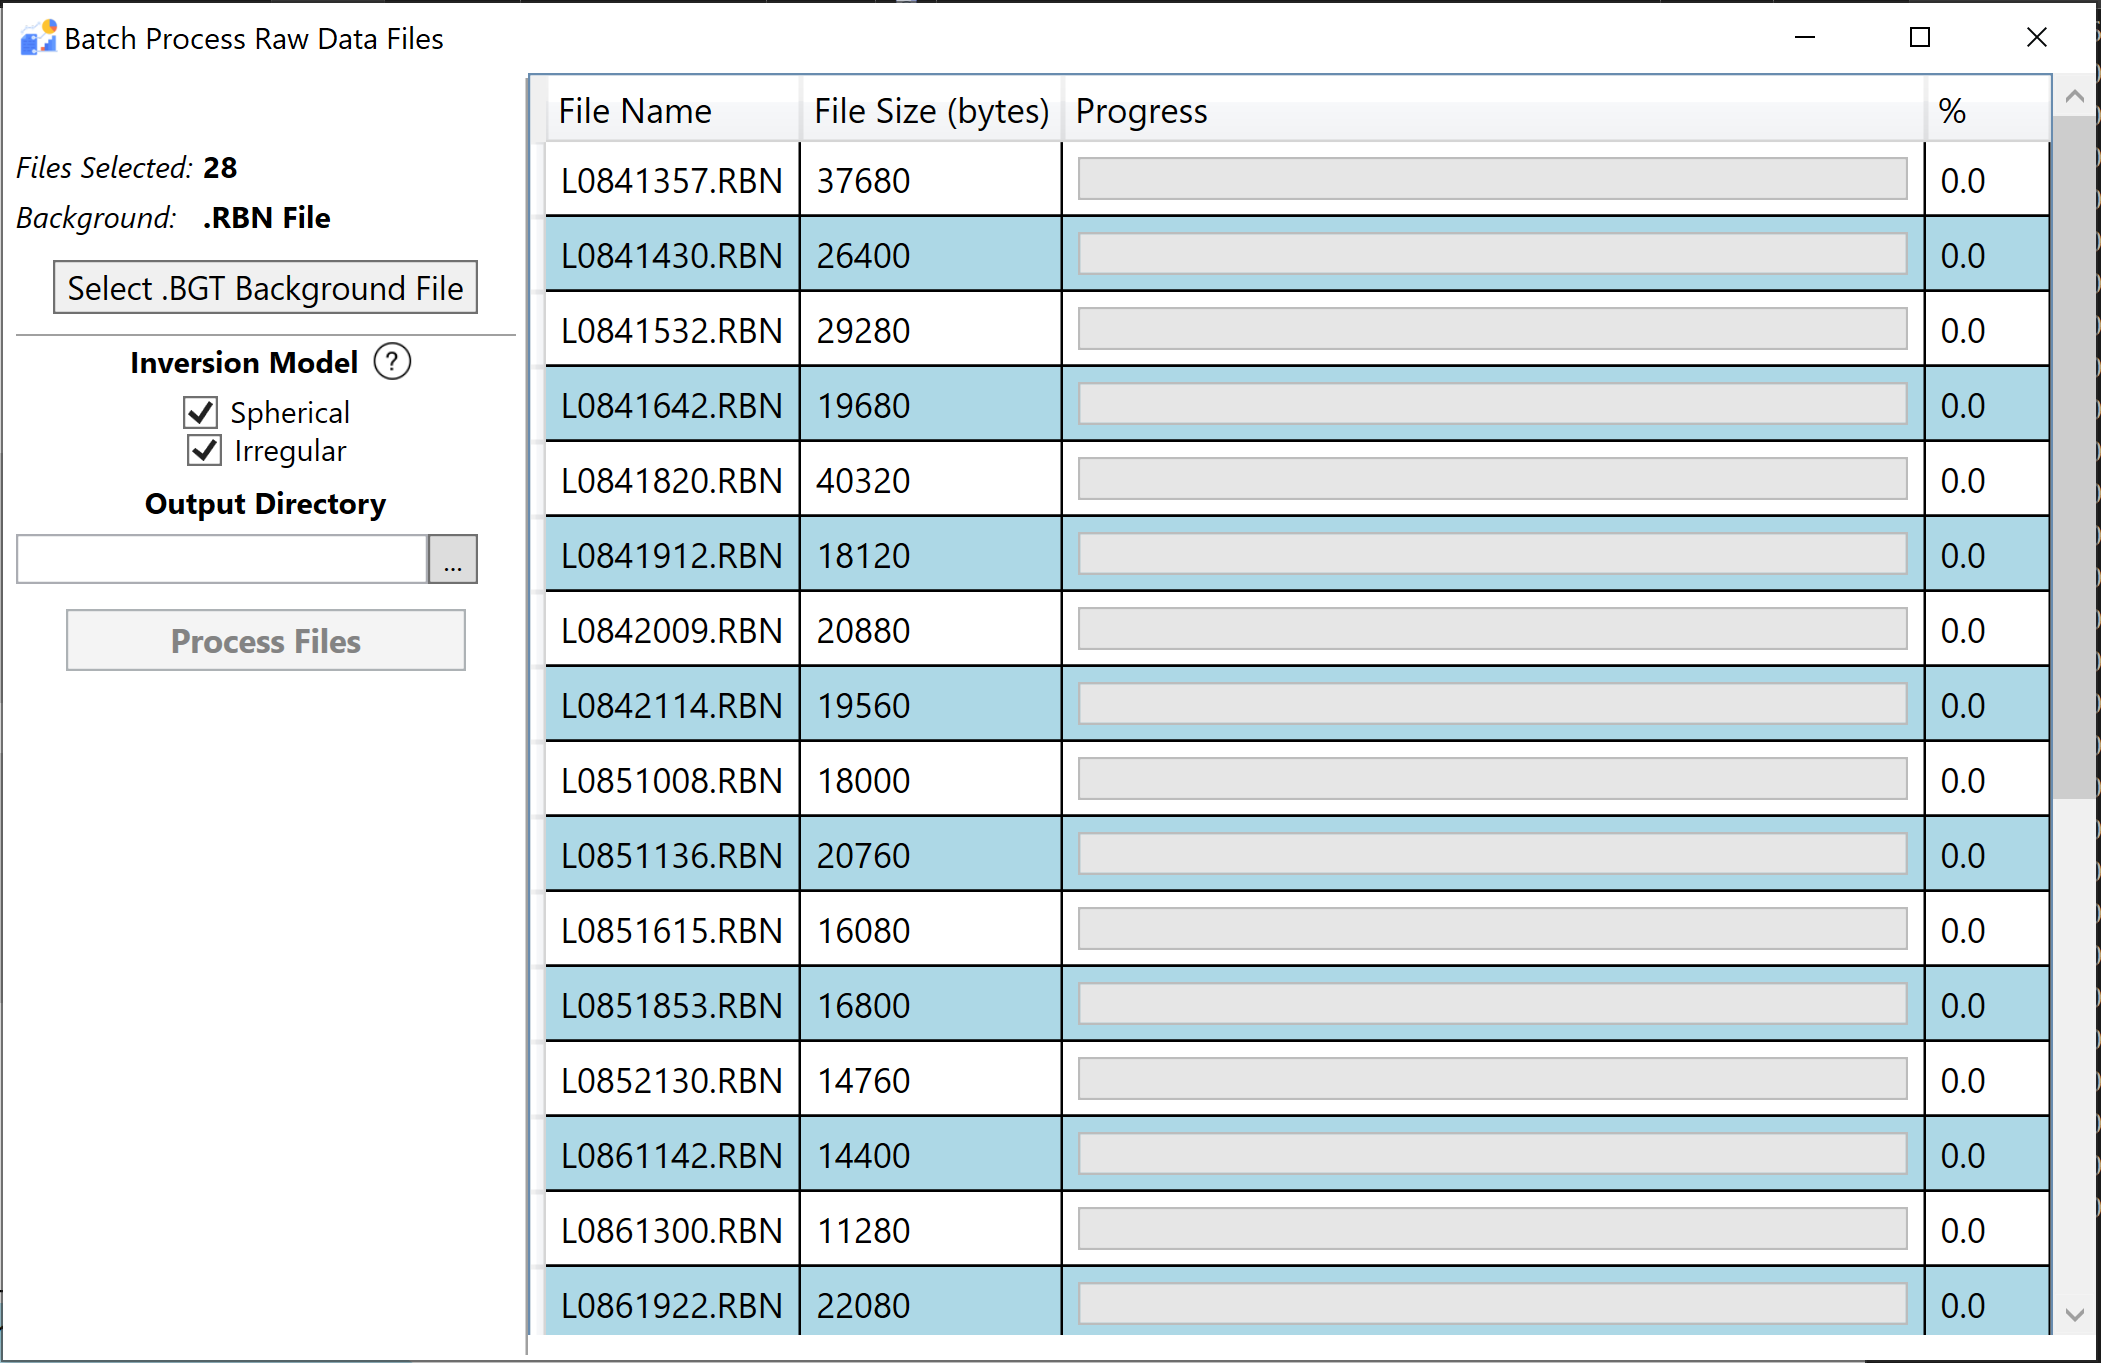    
</div>
5. Choose the 'Output Directory' (I chosse the same I read the RBNs
6. For each .RBN, it generate 3 other files with the same name, one adding '_rs', with extensions 'csv' and 'rtx', all are ASCII
7. The .csv file (without '_rs') has the fields below (separated by space)
<div>
    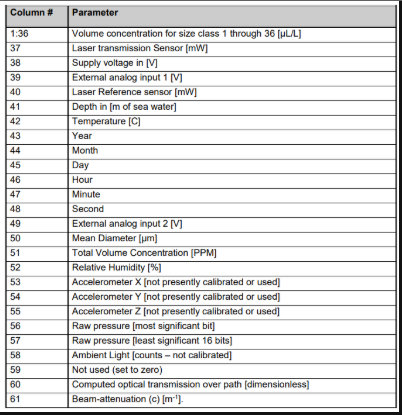
</div>


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [5]:
path = r'd:\GUTO\1_Trabs\1_Aestus\Lagoa_dos_Patos\AnthroPlast_Felipe\Campanha_2025Abril\LISST_rbn\\'

listdir = os.listdir(path)

# getting the file names
csv = []
for f in listdir:
    if '_rs' not in f and f.endswith('csv') == True:
        csv.append(f)

### Processing one for example

In [27]:
with open(path + csv[5]) as io:
    lines = io.readlines()

print(csv[5])
print(len(lines[0].split()))
print(lines[0])

L0841912.csv
61
0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0557, 0.6054, 4.6621, 4.3824, 2.4935, 6.2139, 7.5173, 9.2545, 11.1596, 12.3459, 13.5368, 14.7046, 14.5038, 13.1846, 11.2231, 10.2778, 10.2284, 10.2132, 10.1862, 10.9539, 11.1591, 11.9409, 17.0385, 21.4150, 16.4672, 2.6319, 0.0309, 0.5932, 11.27, 0.000, 0.9690, -0.36, 26.123, 2025, 3, 25, 19, 13, 1, 1.288, 71.50, 258.3862, 41, 2847, 3266, 2764, 0, 22469, 4748, 0.012, 0.602, 20.312



# Creating a dictionary do organize the data 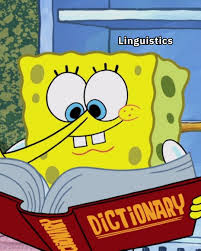

In [25]:
lisst_dic_keys = ['volume concentration', 'depth', 'temperature', 'mean diameter', 'total volume concentration']
# indexes of the things we need
indexes = [slice(0,36), 40, 41, 49, 50]

lisst_dic = {}
lisst_dic['time'] = []

for key in lisst_dic_keys:
    lisst_dic[key] = []

for line in lines:
    line = line.strip()
    line = line.split(',')
    line = [float(x) for x in line]
    
    for idx, key in zip(indexes, lisst_dic_keys):
        lisst_dic[key].append(line[idx])

    # to create the datetime
    ints = [int(x) for x in line[42:48]]
    time = datetime.datetime(ints[0], ints[1], ints[2], ints[3], ints[4], ints[5])
    lisst_dic['time'].append(time)

In [24]:
lisst_dic.keys()

dict_keys(['time', 'volume concentration', 'depth', 'temperature', 'mean diameter'])

### From the manual
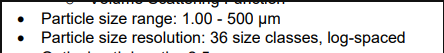

In [32]:
size_classes = np.logspace(np.log10(1), np.log10(500), 36)

lisst_dic['size classes'] = size_classes

print(lisst_dic['size classes'])

[  1.           1.19429999   1.42635247   1.70349274   2.03448136
   2.42978107   2.9018875    3.46572422   4.1391144    4.94334428
   5.90383603   7.05095131   8.42095108  10.05714179  12.01124434
  14.345029    17.13226799  20.46106749  24.4366527   29.18469407
  34.85527984  41.62766037  49.71591437  59.37571604  70.91241707
  84.690699   101.14610098 120.7987874  144.26999059 172.30164833
 205.77985689 245.76288104 293.51460639 350.5444915  418.65528272
 500.        ]


# Checking if we are doing OK

### By the proprietary software
<div>
    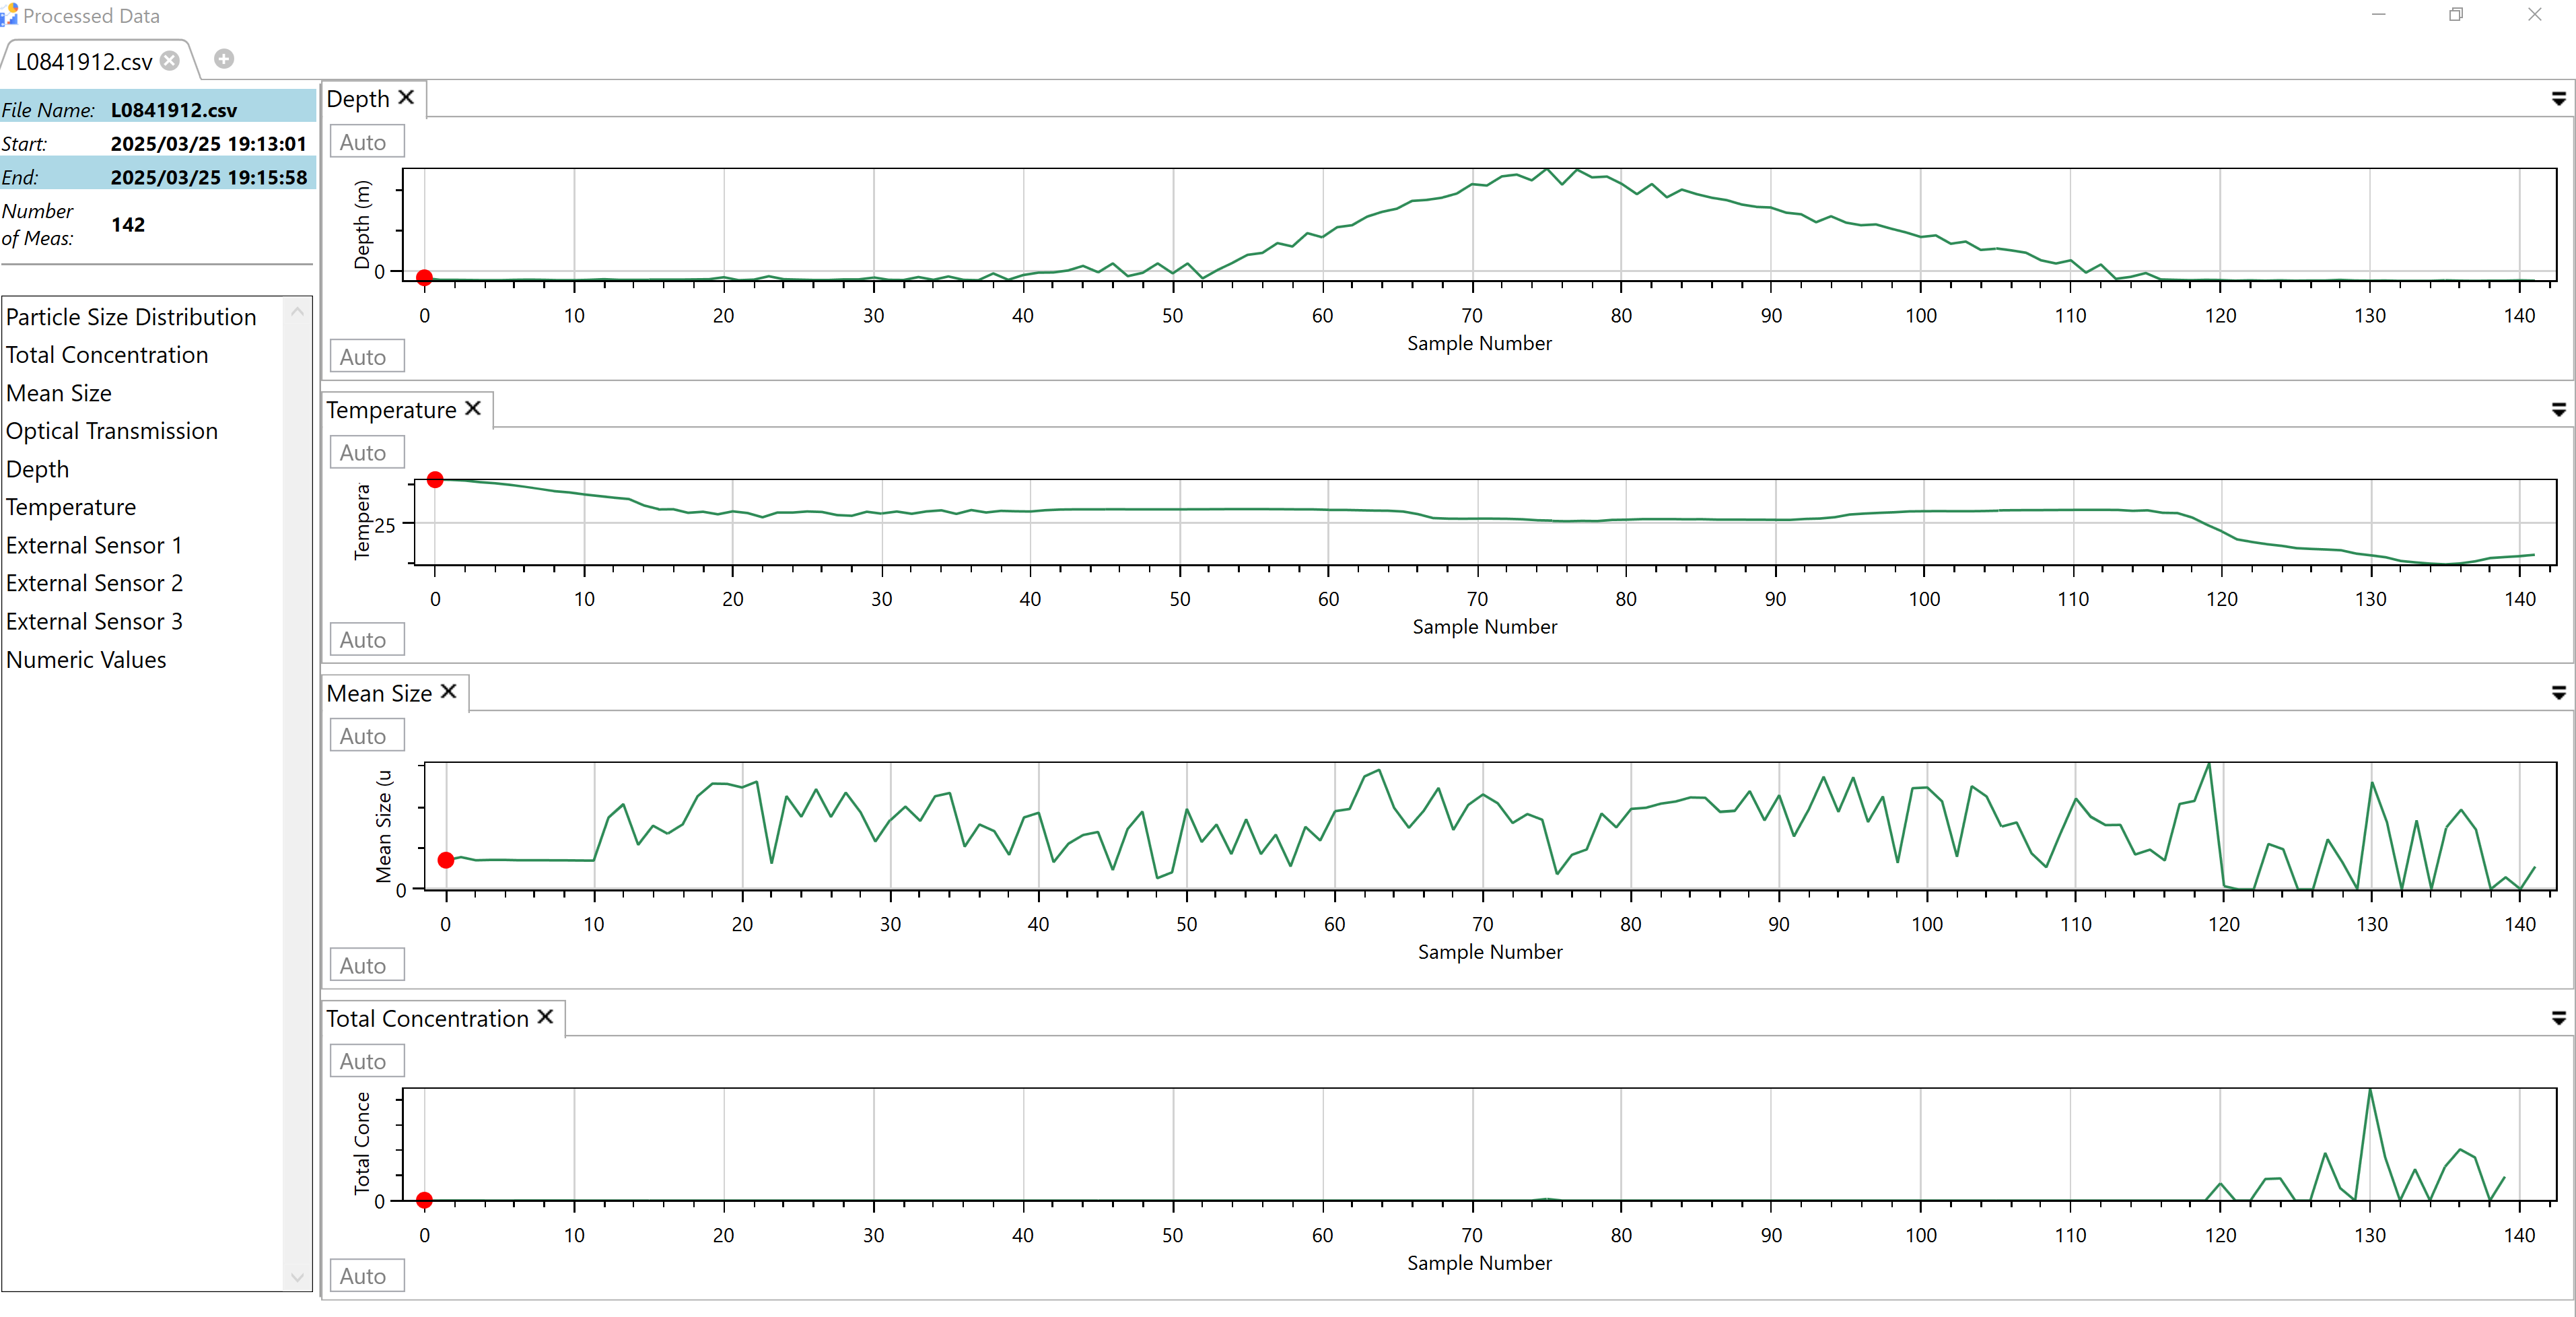
</div>

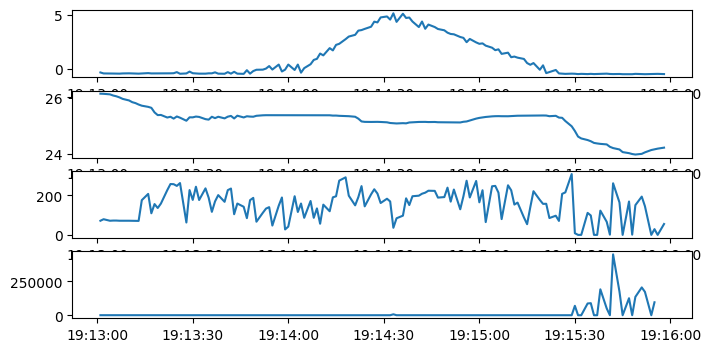

In [28]:
fig, axs = plt.subplots(4, figsize=(8,4)) 
axs[0].plot(lisst_dic['time'], lisst_dic['depth'])
axs[1].plot(lisst_dic['time'], lisst_dic['temperature'])
axs[2].plot(lisst_dic['time'], lisst_dic['mean diameter'])
axs[3].plot(lisst_dic['time'], lisst_dic['total volume concentration'])

### The Particle size distribution based on the volume concentration, the first measurement of the file

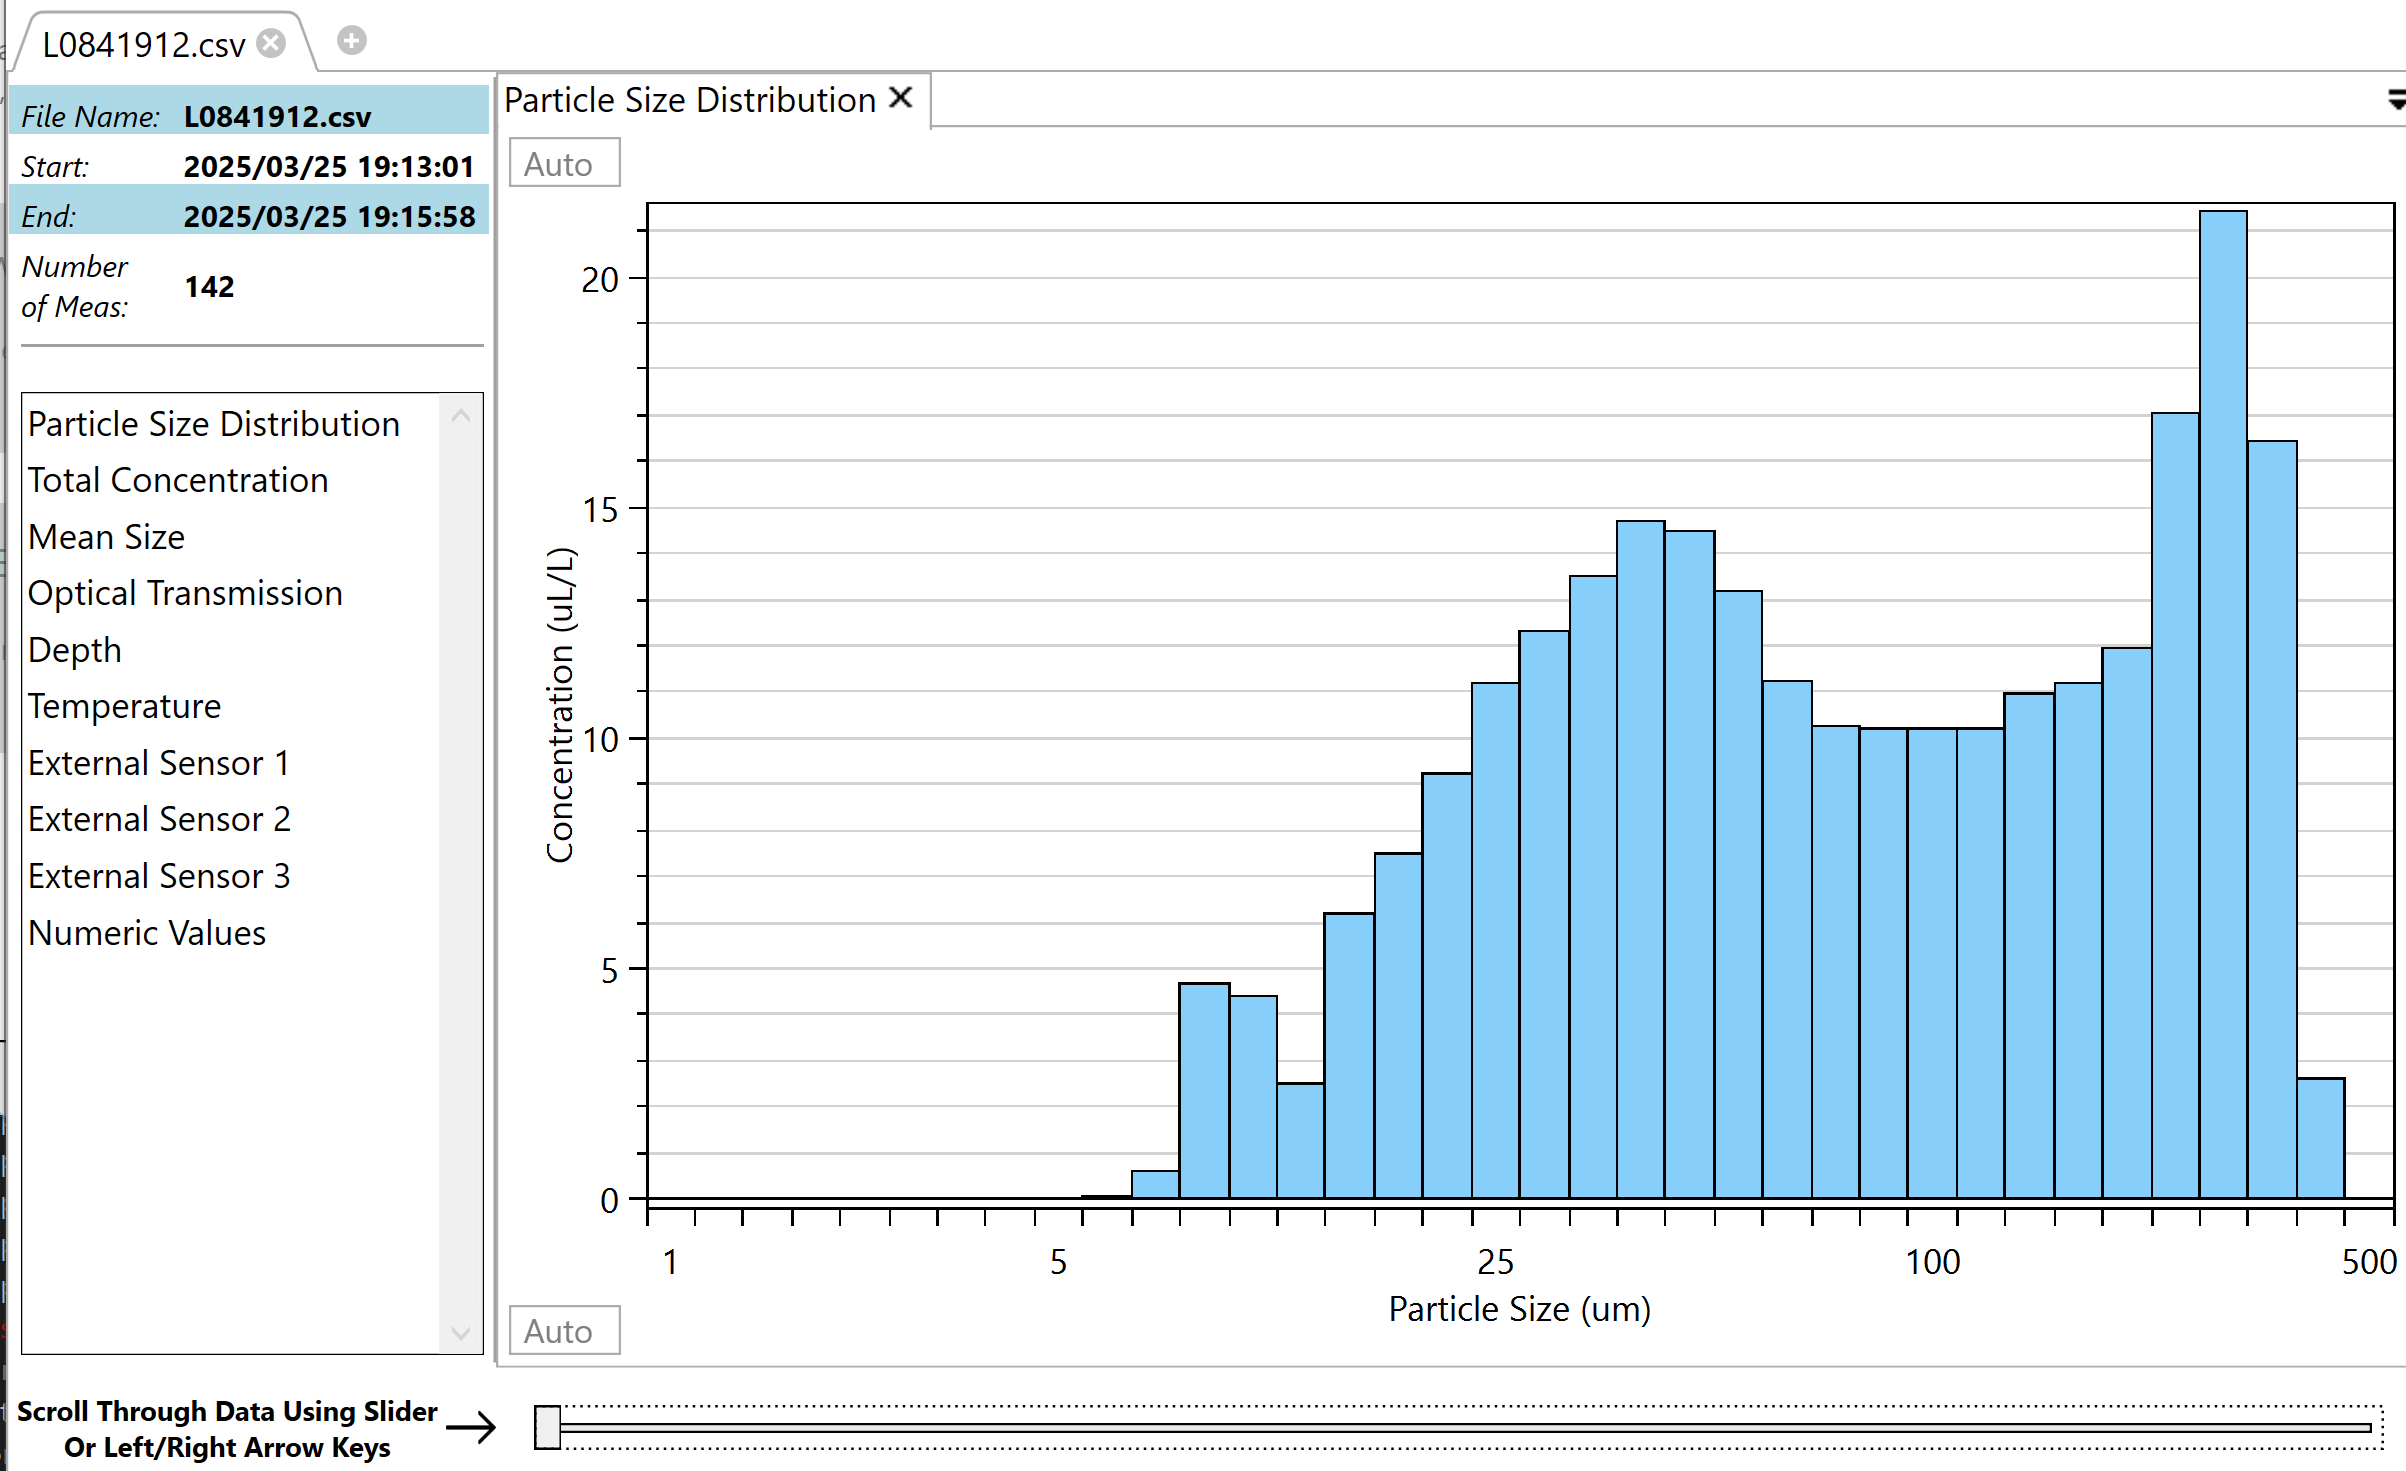

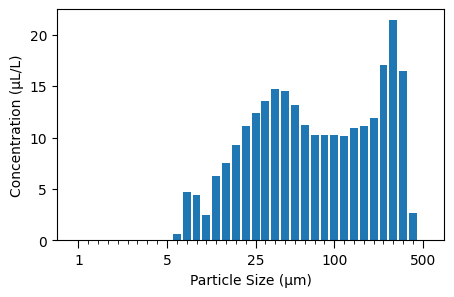

In [35]:
fig, ax = plt.subplots(figsize=(5,3))

ax.bar(range(len(lisst_dic['size classes'])), lisst_dic['volume concentration'][0]) 

xticks = [0, 9, 18, 26, 35]
ax.set_xticks(xticks)

# define quais labels aparecem nesses ticks
xticklabels = ['1', '5', '25', '100', '500']
ax.set_xticklabels(xticklabels)

# ticks secundários (sem rótulos)
xticks_minor = np.arange(0, 36, 1)
ax.set_xticks(xticks_minor, minor=True)

# mostrar também os ticks secundários
ax.tick_params(axis='x', which='minor', length=3)       # marca pequena
ax.tick_params(axis='x', which='major', length=6)       # marca maior

ax.set_ylabel('Concentration (µL/L)')
ax.set_xlabel('Particle Size (µm)')

plt.show()